In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import polars as pl
import matplotlib.pyplot as plt
from primary.preprocessing import cluster_purity
import plotly.express as px
import numpy as np
from primary.pdg_mappings import PDG_ID_TO_NAME

import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from collections import defaultdict, deque

/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/sklearn/utils/_param_validation.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy.sparse import csr_matrix, issparse


In [3]:
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()


with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_particles/train-00000-of-00100.parquet", "rb") as f:
    particles = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_calo_hits/train-00000-of-00100.parquet", "rb") as f:
    calo_hits = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracks/train-00000-of-00100.parquet", "rb") as f:
    tracks = pl.read_parquet(f)


In [4]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_mask
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles = set_target_particles_mask(particles)
particles


Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 4204335 depositors.
Preparing lineage map...
Converged after 5 iterations.


event_id,is_target_particle,enter_calo,has_track,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary,is_parent_missing,created_inside_calo,eta,phi,pt
u32,list[bool],list[bool],list[bool],list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool],list[bool],list[bool],list[f32],list[f32],list[f32]
225,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[92, 93, … 8152]","[2224, -2214, … 2212]","[1.142196, 1.376007, … 0.938272]","[197.421478, 38.741081, … 1.392178]","[2.0, -1.0, … 1.0]","[-0.007473, -0.007473, … 1193.659546]","[-0.00711, -0.00711, … 543.52063]","[-35.744984, -35.744984, … -797.78717]","[-0.390174, -0.390174, … 4.92509]","[-0.07332, -0.044147, … 0.775188]","[-0.072443, 0.116699, … 0.570143]","[197.418152, 38.716434, … 0.363077]","[NaN, NaN, … NaN]","[NaN, NaN, … NaN]","[1, 1, … 1]","[9, 9, … 793]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[8.250802, 6.430698, … 0.368887]","[-2.362215, 1.932452, … 0.63415]","[0.103072, 0.12477, … 0.962279]"
109,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[55, 56, … 4410]","[5122, -313, … -11]","[5.6194, 0.876206, … 0.000511]","[260.990601, 57.815388, … 0.104661]","[0.0, 0.0, … 1.0]","[-0.001518, -0.001518, … 453.871094]","[-0.002497, -0.002497, … 1082.815918]","[-123.408867, -123.408867, … 1425.342651]","[0.095225, 0.095225, … 6.583069]","[45.297935, 0.149335, … 0.024946]","[-7.938653, 0.135229, … 0.057742]","[256.845459, 57.808395, … 0.083649]","[-0.002721, 0.0, … NaN]","[-123.402924, 0.0, … NaN]","[1, 1, … 1]","[8, 8, … 4408]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[2.421155, 6.352429, … 1.096536]","[-0.173492, 0.735871, … 1.162981]","[45.988316, 0.201464, … 0.0629]"
639,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[15, 16, … 5275]","[321, -321, … 11]","[0.49368, 0.49368, … 0.000511]","[2659.132568, 262.903412, … 0.216813]","[1.0, -1.0, … -1.0]","[0.000264, 0.000264, … 876.002808]","[-0.00724, -0.00724, … 298.058868]","[-98.451248, -98.451248, … -3221.205078]","[0.183122, 0.183122, … 11.047185]","[-0.601844, 0.601844, … 0.057877]","[-0.007716, 0.007716, … 0.019829]","[2659.132568, 262.902252, … -0.208002]","[NaN, NaN, … 600.870361]","[NaN, NaN, … 4852.755371]","[1, 1, … 1]","[9, 9, … 5229]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[9.086577, 6.772606, … -1.937842]","[-3.128773, 0.012819, … 0.33007]","[0.601894, 0.601894, … 0.061179]"
883,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[143, 144, … 3732]","[-513, 221, … 11]","[5.3252, 0.54785, … 0.000511]","[51.994095, 1.271851, … 0.000865]","[0.0, 0.0, … -1.0]","[-0.003428, -0.003428, … -241.122711]","[0.025299, 0.025299, … -439.749054]","[-8.418909, -8.418909, … -156.818329]","[0.040326, 0.040326, … 10.324431]","[-9.241463, -0.082966, … -0.000137]","[1.38283, 0.211147, … -0.00068]","[50.869553, 1.125166, … 0.000071]","[-0.024514, -0.006061, … NaN]","[-8.457748, -8.541913, … NaN]","[1, 1, … 1]","[9, 9, … 555]","[true, true, … false]","[true, true, … false]","[false, false, … false]","[2.395971, 2.304502, … 0.102822]","[2.993061, 1.945193, … -1.769699]","[9.344349, 0.226862, … 0.000694]"
353,"[true, false, … false]","[true, false, … false]","[true, false, … false]","[71, 72, … 4165]","[211, 3112, … -11]","[0.13957, 1.19745, … 0.000511]","[3.380572, 13.182285, … 0.154752]","[1.0, -1.0, … 1.0]","[0.003857, 0.003857, … 1111.433716]","[-0.012309, -0.012309, … 610.687988]","[47.929626, 47.929626, … 2496.539307]","[0.062006, 0.062006, … 9.261945]","[0.790852, 3.060348, … 0.066863]","[1.165092, -0.403116, … 0.034356]","[3.070163, 12.759724, … 0.135266]","[-0.010104, -0.011699, … NaN]","[47.947105, 47.907173, … NaN]","[1, 1, … 1]","[18, 18, …

In [39]:
import awkward as ak
import fastjet
import math  # For potential calculations, though not strictly needed here
from primary.calibration import CALIBRATION

N_events = 100
for i in range(N_events):
    event_idx = i  # Change this to select different events
    calo_e = (
        calo_hits.lazy()
            .select('x', 'y', 'z', 'total_energy', 'detector', 'event_id')
        .explode('x', 'y', 'z', 'total_energy', 'detector')
        .filter(pl.col("event_id") == event_idx)

        .join(
            CALIBRATION.lazy(),
            left_on=['detector'],
            right_on=['detector'],
            how="inner"
        )
        .with_columns((pl.col('total_energy') * pl.col('calib_factor')).alias('total_energy'))).collect()
    energies = calo_e['total_energy']
    x = calo_e['x'].to_numpy()
    y = calo_e['y'].to_numpy()
    z = calo_e['z'].to_numpy()


    print(f"Number of calorimeter deposits in event {event_idx}: {len(energies)}")
    # Compute the distance r for each cell
    r = np.sqrt(x**2 + y**2 + z**2)

    # Compute the four-momentum components assuming massless approximation
    # px, py, pz = (energies * coord / r) for coord in (x, y, z)
    # E = energies (deposited energy)
    px = energies * x / r
    py = energies * y / r
    pz = energies * z / r
    E = energies

    particles_with_id = []
    for i in range(len(px)):
        pj = fastjet.PseudoJet(px[i], py[i], pz[i], E[i])
        pj.set_user_index(i)  # <--- Stores the original index 'i'
        particles_with_id.append(pj)

    # 2. Run Clustering (Inclusive, ptmin=0.0 to keep ALL cells)
    R = 0.4
    jet_def = fastjet.JetDefinition(fastjet.kt_algorithm, R)
    cs = fastjet.ClusterSequence(particles_with_id, jet_def)
    partitions = cs.inclusive_jets(ptmin=0.0)

    # ---------------------------------------------------------
    # 3. Generate the Label Array
    # ---------------------------------------------------------

    # Initialize with -1 to detect any missing cells (though ptmin=0.0 prevents this)
    num_cells = len(px)
    cluster_labels = np.full(num_cells, -1, dtype=np.int32)

    # Iterate over each cluster and assign its ID to the constituent cells
    for cluster_id, partition in enumerate(partitions):
        # Get the original indices of cells in this cluster
        constituents = partition.constituents()
        
        for c in constituents:
            original_idx = c.user_index()
            cluster_labels[original_idx] = cluster_id

    # ---------------------------------------------------------
    # 4. Result
    # ---------------------------------------------------------
    print("Cluster Labels:", cluster_labels)






Number of calorimeter deposits in event 0: 9472
Cluster Labels: [ 2  2  2 ...  0  1 12]
Number of calorimeter deposits in event 1: 16636
Cluster Labels: [ 0 15  9 ...  5  4  5]
Number of calorimeter deposits in event 2: 19814
Cluster Labels: [ 7  1  2 ...  2 40 11]
Number of calorimeter deposits in event 3: 21088
Cluster Labels: [64  6 16 ...  4 19 17]
Number of calorimeter deposits in event 4: 12553
Cluster Labels: [40  0 25 ...  1  3  4]
Number of calorimeter deposits in event 5: 31865
Cluster Labels: [27  2  5 ...  1  6  5]
Number of calorimeter deposits in event 6: 31353
Cluster Labels: [ 7  2  2 ... 66  9  6]
Number of calorimeter deposits in event 7: 43951
Cluster Labels: [ 0  2 36 ...  0  3  0]
Number of calorimeter deposits in event 8: 30892
Cluster Labels: [ 2  6 21 ...  1  1  0]
Number of calorimeter deposits in event 9: 36860
Cluster Labels: [0 1 9 ... 5 0 7]
Number of calorimeter deposits in event 10: 34552
Cluster Labels: [ 1  9 42 ... 22  1  1]
Number of calorimeter depos

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f2a1cd47bd0>>
Traceback (most recent call last):
  File "/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


Cluster Labels: [ 2  4  2 ...  5 17  0]
Number of calorimeter deposits in event 45: 27570
Cluster Labels: [31  0 19 ...  2  1 35]
Number of calorimeter deposits in event 46: 33911
Cluster Labels: [ 4  6  3 ... 41  1  0]
Number of calorimeter deposits in event 47: 25009
Cluster Labels: [ 7 30 10 ...  7  7  1]
Number of calorimeter deposits in event 48: 28992
Cluster Labels: [1 0 1 ... 1 3 2]
Number of calorimeter deposits in event 49: 44404
Cluster Labels: [28 23 44 ...  2  3  2]
Number of calorimeter deposits in event 50: 34890
Cluster Labels: [2 2 4 ... 1 4 4]
Number of calorimeter deposits in event 51: 23923
Cluster Labels: [4 6 0 ... 7 0 0]
Number of calorimeter deposits in event 52: 39216
Cluster Labels: [54  2  2 ...  0  2 12]
Number of calorimeter deposits in event 53: 28878
Cluster Labels: [12 15 27 ...  2 30  2]
Number of calorimeter deposits in event 54: 45315
Cluster Labels: [19  2  0 ...  0  0 61]
Number of calorimeter deposits in event 55: 31589
Cluster Labels: [4 6 2 ... 0

In [30]:
all_constituents = cs.constituents()
sum_len = sum([len(c) for c in all_constituents])
max_len = max([len(c) for c in all_constituents])
num_of_jets = len(all_constituents)
print(f"Total number of constituents across all jets: {sum_len}, original deposits: {len(energies)}, max constituents in a jet: {max_len}, number of jets: {num_of_jets}")

Total number of constituents across all jets: 43951, original deposits: 43951, max constituents in a jet: 8787, number of jets: 72


In [12]:
from primary.preprocessing import add_cluster_labels
calo = add_cluster_labels(
    calo_hits=(
        calo_hits.filter(pl.col("event_id") <100)
    ), R=0.4)

Clustering 100 events...


In [6]:
from primary.preprocessing import backtrack_to_target
target = (particles.lazy()
        .select(['event_id','particle_id', 'is_target_particle'])
          .explode(['is_target_particle', 'particle_id'])
          .filter(pl.col('is_target_particle'))
          ).collect(streaming=True)
base  =(
        calo_hits.lazy()
        .select(['event_id', 'contrib_particle_ids'])
        .explode('contrib_particle_ids')
        .explode('contrib_particle_ids') # Double explode if list[list]
        .rename({'contrib_particle_ids': 'particle_id'})
        .unique(subset=['event_id', 'particle_id'])
        .select([
            pl.col('event_id'),
            pl.col('particle_id').cast(pl.Int64)
        ])
    )
result = backtrack_to_target(particles, src_df=base, target_df=target)
result

/tmp/ipykernel_2693847/2526740024.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 12 iterations.
Step 4: Final validation...


event_id,src_particle_id,target_particle_id
u32,i64,i64
35,2195,2165
35,2173,2165
35,2213,2165
35,2211,2165
37,661,636
…,…,…
960,5874,5803
960,2215,377
960,5029,5020


In [10]:
from primary.preprocessing import cluster_purity
pur = cluster_purity(calo, result)

In [24]:
from primary.preprocessing import cluster_stats
s = cluster_stats(calo, result)
s

event_id,cluster_id,num_contributing_ancestors,max_ancestor_energy_deps_in_cluster,cluster_total_energy
u32,i64,u32,f64,f64
43,55,5,0.349711,1.201507
96,66,3,0.701707,1.441835
49,75,7,0.501764,1.818368
49,17,2,3.439192,6.61418
84,1,9,13.118468,120.754758
…,…,…,…,…
14,44,1,2.077929,2.077929
54,64,1,0.775531,0.807326
31,80,1,0.138053,0.138053


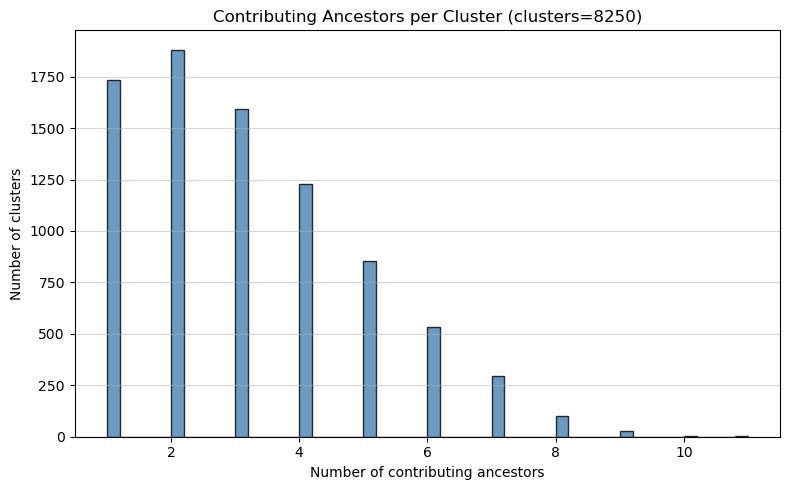

In [26]:
# ...existing code...
def plot_num_contributing_ancestors(cluster_stats_df: pl.DataFrame, bins: int = 50, log_scale: bool = False) -> None:
    """
    Histogram of 'num_contributing_ancestors' from cluster_stats output.
    Expects schema: event_id, cluster_id, num_contributing_ancestors, ...
    """
    vals = cluster_stats_df["num_contributing_ancestors"].to_numpy()
    plt.figure(figsize=(8, 5))
    plt.hist(vals, bins=bins, color="steelblue", edgecolor="black", alpha=0.8)
    plt.xlabel("Number of contributing ancestors")
    plt.ylabel("Number of clusters")
    plt.title(f"Contributing Ancestors per Cluster (clusters={len(vals)})")
    if log_scale:
        plt.yscale("log")
        plt.ylabel("Number of clusters (log scale)")
    plt.grid(axis="y", alpha=0.5)
    plt.tight_layout()
    plt.show()
# ...existing code...

plot_num_contributing_ancestors(s, log_scale=False)

/tmp/ipykernel_2693847/3461637387.py:6: DeprecationWarning: `count` was renamed; use `len` instead
  .count()
/tmp/ipykernel_2693847/3461637387.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("num_clusters"),


,event_id,num_clusters,max_cluster_size
0,0,73,2424
1,1,73,3186
2,2,75,4697
3,3,83,2693
4,4,88,2496
...,...,...,...
95,95,86,2959
96,96,97,4191
97,97,85,15708
98,98,89,4929


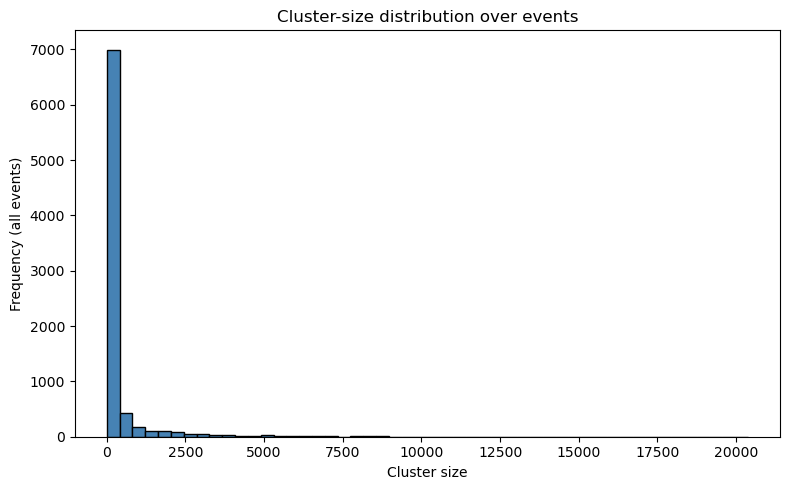

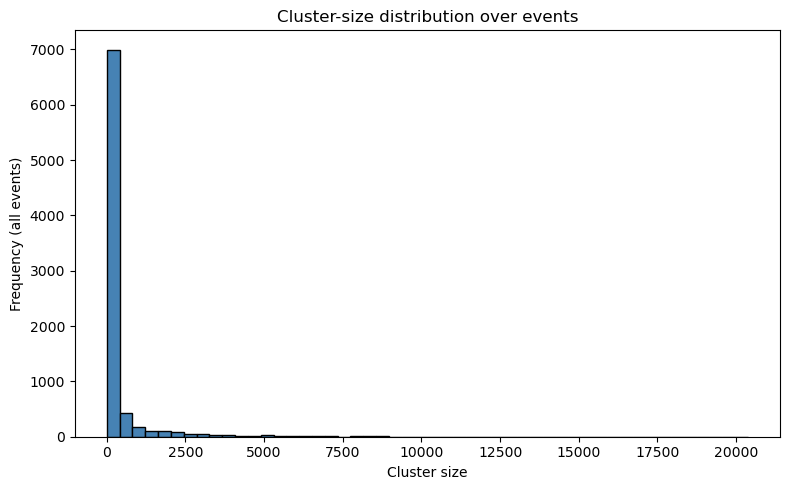

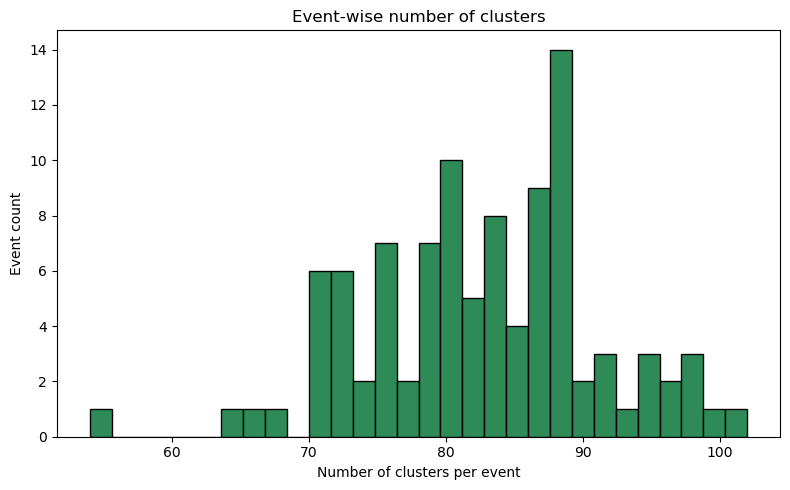

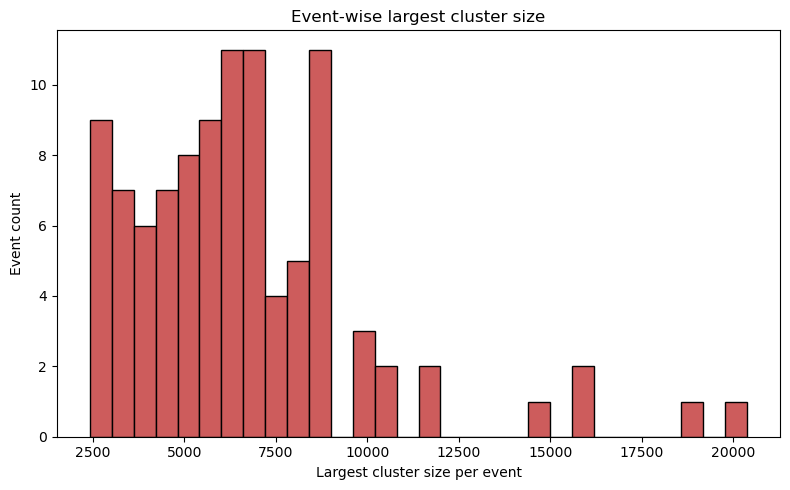

In [18]:
cluster_stats = (
    calo.lazy()
    .select(["event_id", "cluster_id"])
    .explode("cluster_id")
    .group_by(["event_id", "cluster_id"])
    .count()
    .rename({"count": "cluster_size"})
    .collect()
)

event_summary = (
    cluster_stats.lazy()
    .group_by("event_id")
    .agg([
        pl.count().alias("num_clusters"),
        pl.col("cluster_size").max().alias("max_cluster_size"),
    ])
    .sort("event_id")
    .collect()
)

display(event_summary.to_pandas())

plt.figure(figsize=(8, 5))
plt.hist(cluster_stats["cluster_size"].to_numpy(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Cluster size")
plt.ylabel("Frequency (all events)")
plt.title("Cluster-size distribution over events")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(cluster_stats["cluster_size"].to_numpy(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Cluster size")
plt.ylabel("Frequency (all events)")
plt.title("Cluster-size distribution over events")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(event_summary["num_clusters"].to_numpy(), bins=30, color="seagreen", edgecolor="black")
plt.xlabel("Number of clusters per event")
plt.ylabel("Event count")
plt.title("Event-wise number of clusters")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(event_summary["max_cluster_size"].to_numpy(), bins=30, color="indianred", edgecolor="black")
plt.xlabel("Largest cluster size per event")
plt.ylabel("Event count")
plt.title("Event-wise largest cluster size")
plt.tight_layout()
plt.show()

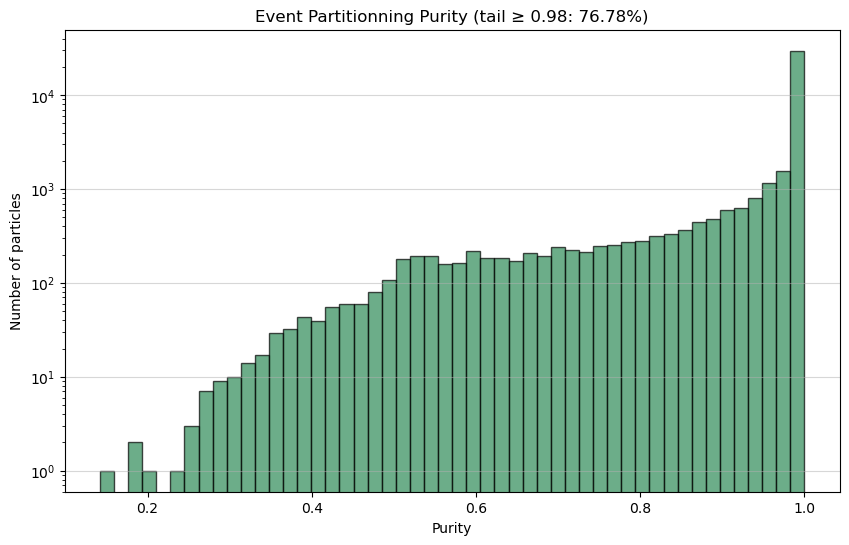

In [22]:
from primary.plot import plot_clusters_purity
purity_df = plot_clusters_purity(calo, result)

/tmp/ipykernel_2502228/2526740024.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 12 iterations.
Step 4: Final validation...


event_id,src_particle_id,target_particle_id
u32,i64,i64
7,8378,8168
7,8210,8168
7,8374,8168
7,8230,8168
7,8237,8168
…,…,…
509,4365,875
509,4361,875
510,1070,1070


In [35]:
import fastjet
import numpy as np

# 1. Prepare Data & Set Indices
# It is CRITICAL to set_user_index(i) so we know which cell is which after clustering
particles_with_id = []
for i in range(len(px)):
    pj = fastjet.PseudoJet(px[i], py[i], pz[i], E[i])
    pj.set_user_index(i)  # <--- Stores the original index 'i'
    particles_with_id.append(pj)

# 2. Run Clustering (Inclusive, ptmin=0.0 to keep ALL cells)
R = 0.4
jet_def = fastjet.JetDefinition(fastjet.kt_algorithm, R)
cs = fastjet.ClusterSequence(particles_with_id, jet_def)
partitions = cs.inclusive_jets(ptmin=0.0)

# ---------------------------------------------------------
# 3. Generate the Label Array
# ---------------------------------------------------------

# Initialize with -1 to detect any missing cells (though ptmin=0.0 prevents this)
num_cells = len(px)
cluster_labels = np.full(num_cells, -1, dtype=np.int32)

# Iterate over each cluster and assign its ID to the constituent cells
for cluster_id, partition in enumerate(partitions):
    # Get the original indices of cells in this cluster
    constituents = partition.constituents()
    
    for c in constituents:
        original_idx = c.user_index()
        cluster_labels[original_idx] = cluster_id

# ---------------------------------------------------------
# 4. Result
# ---------------------------------------------------------
print("Cluster Labels:", cluster_labels)

# Verification
if -1 in cluster_labels:
    print("WARNING: Some cells were not assigned to a cluster!")
else:
    print("Success: All cells assigned.")

# Example Output check
# If cells 0 and 1 are in cluster 5, and cells 2 and 3 are in cluster 8:
# Output: [5, 5, 8, 8, ...]

Cluster Labels: [ 0  2 36 ...  0  3  0]
Success: All cells assigned.


In [36]:
cluster_labels

array([ 0,  2, 36, ...,  0,  3,  0], shape=(43951,), dtype=int32)

In [34]:
constituents[0].user_index()

39578

In [6]:
(
    calo_hits.lazy()
    .filter(pl.col("event_id") == 5)
    .select('x', 'y', 'z', 'total_energy')
    .explode('x', 'y', 'z', 'total_energy')
).collect(streaming=True)

/tmp/ipykernel_2501669/974053181.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


x,y,z,total_energy
f32,f32,f32,f32
353.82843,505.29071,3263.0,0.000127
-439.516754,-1260.991455,40.799999,0.000505
1129.478394,313.279694,3318.550049,0.018525
-86.699997,1272.599976,1203.599976,0.001721
-56.099998,367.788971,3232.699951,0.000137
…,…,…,…
927.221313,-681.996704,3293.300049,0.000211
-681.996704,-537.746887,3323.600098,0.000278
726.764343,-1072.963867,2779.5,0.000352
